In [1]:
import pandas as pd
import seaborn as sns
df=sns.load_dataset('titanic')
print(df.shape)
print(df.head())
df.isna().sum()

(891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [2]:
def preda(df):
    print(f"Shape:{df.shape}")
    print(f"\nMissing:\n{df.isna().sum()}")
    print(f"\nTypes:\n{df.dtypes}")
    print(f"\nStats:\n{df.describe()}")
    print(f"\nsample:\n{df.head()}")
preda(df)

Shape:(891, 15)

Missing:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Stats:
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.10274

In [3]:
# Fixing the Age columns
df['age'].fillna(df['age'].median(),inplace=True)
# Fixing Embark column
df['embark_town'].fillna(df['embark_town'].mode()[0],inplace=True)
# Drop Deck
df.drop(columns=['deck'],inplace=True)
# Check out
df.isna().sum()
df['embarked'].fillna(df['embarked'].mode()[0],inplace=True)
df

C:\Users\ayush\AppData\Local\Temp\ipykernel_24496\896058447.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(),inplace=True)
C:\Users\ayush\AppData\Local\Temp\ipykernel_24496\896058447.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [4]:
print(df['survived'].value_counts())
print(df.groupby('survived')['fare'].mean())
print(df.groupby(['survived','sex']).count())
print(df.groupby(['survived','sex'])['who'].count())
print(df.groupby(['survived','pclass'])['who'].count())

survived
0    549
1    342
Name: count, dtype: int64
survived
0    22.117887
1    48.395408
Name: fare, dtype: float64
                 pclass  age  sibsp  parch  fare  embarked  class  who  \
survived sex                                                             
0        female      81   81     81     81    81        81     81   81   
         male       468  468    468    468   468       468    468  468   
1        female     233  233    233    233   233       233    233  233   
         male       109  109    109    109   109       109    109  109   

                 adult_male  embark_town  alive  alone  
survived sex                                            
0        female          81           81     81     81  
         male           468          468    468    468  
1        female         233          233    233    233  
         male           109          109    109    109  
survived  sex   
0         female     81
          male      468
1         female    233
     

Text(0.5, 1.0, 'Survival by Gender')

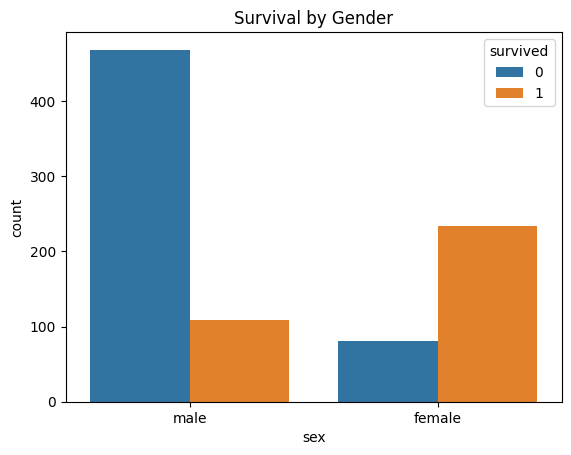

In [5]:
import matplotlib.pyplot as plt
sns.countplot(x='sex',hue='survived',data=df)
plt.title('Survival by Gender')

Text(0.5, 0, 'Passenger Class')

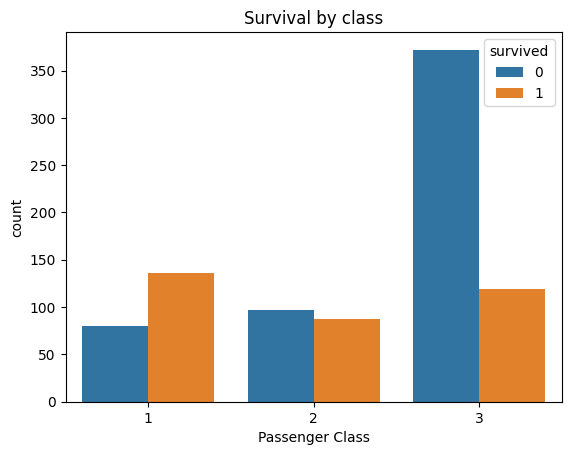

In [6]:
sns.countplot(x='pclass',hue='survived',data=df)
plt.title('Survival by class')
plt.xlabel('Passenger Class')

(0.0, 300.0)

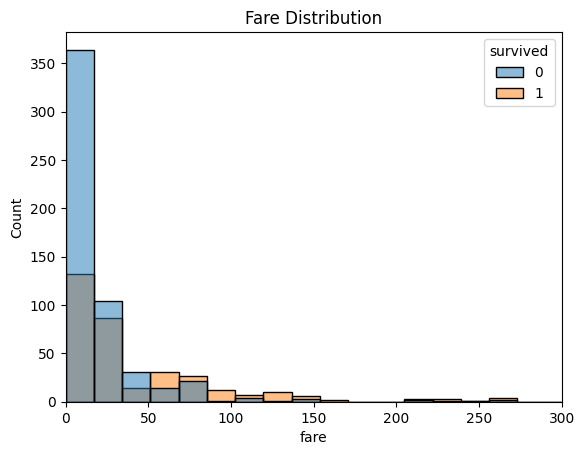

In [7]:
sns.histplot(data=df,x='fare',hue='survived',bins=30)
plt.title('Fare Distribution')
plt.xlim(0,300)

In [8]:
df.columns
df.isna().sum()
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [9]:
df.drop(columns=['alive','who','embark_town','adult_male'],inplace=True)
# Label Encoding
df['sex']=df['sex'].map({'male':0,'female':1})
# One Hot Encoding
df=pd.get_dummies(df,columns=['embarked'],drop_first=True)


In [10]:
print(df.head())
df['sex'].unique()
df['sex'].value_counts()

   survived  pclass  sex   age  sibsp  parch     fare  class  alone  \
0         0       3    0  22.0      1      0   7.2500  Third  False   
1         1       1    1  38.0      1      0  71.2833  First  False   
2         1       3    1  26.0      0      0   7.9250  Third   True   
3         1       1    1  35.0      1      0  53.1000  First  False   
4         0       3    0  35.0      0      0   8.0500  Third   True   

   embarked_Q  embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  


sex
0    577
1    314
Name: count, dtype: int64

In [11]:
df.columns
df.drop(columns=['class'],inplace=True)
df['alone']=df['alone'].astype(int)
df.columns
df.dtypes
df['embarked_Q']=df['embarked_Q'].astype(int)
df['embarked_S']=df['embarked_S'].astype(int)
df.dtypes

survived        int64
pclass          int64
sex             int64
age           float64
sibsp           int64
parch           int64
fare          float64
alone           int64
embarked_Q      int64
embarked_S      int64
dtype: object

In [12]:
y=df['survived']
X=df.drop(columns=['survived'],axis=1)
print(X.shape)
print(y.shape)

(891, 9)
(891,)


In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
print(X_train.shape)
print(X_test.shape)

(712, 9)
(179, 9)


In [14]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
accuracy_score(y_test,y_pred)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [15]:
from sklearn.ensemble import RandomForestClassifier
rfmodel=RandomForestClassifier(n_estimators=100,random_state=42)
rfmodel.fit(X_train,y_train)
rf_pred=rfmodel.predict(X_test)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
accuracy_score(y_test,rf_pred)
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



sex           0.272790
fare          0.270188
age           0.243338
pclass        0.090914
sibsp         0.040141
parch         0.032792
embarked_S    0.023990
alone         0.016988
embarked_Q    0.008859
dtype: float64


<Axes: >

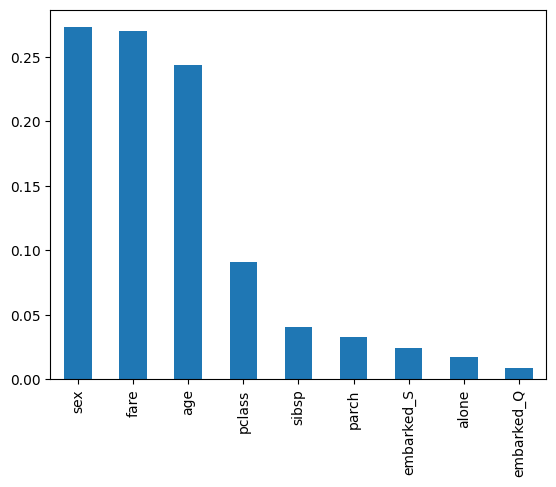

In [16]:
import matplotlib.pyplot as plt
importance=pd.Series(rfmodel.feature_importances_,index=X.columns).sort_values(ascending=False)
print(importance)
importance.plot(kind='bar')